In [2]:
import numpy as np
import matplotlib.pyplot as plt

# NoteBook1
Basics of Stream Power Law (SPL) to illustrate Hack's findings and its application to tectonic geomorphology

The SPL states that the rate of channel incision is proportional to discharge and slope, and that the coefficient of proportionality depends montly on lithology. Mathematically this can be expressed using the following partial differential equation (PDE):

$$\frac{\partial h}{\partial t} = U - K \phi^m S^n$$

where $h$ is surface topographic height, $t$ is time, $U$ is tectonic uplift rate, $\phi$ is discharge in the river and $S$ its slope. The coefficient $K$ is poorly constrained and dependent on lithology. The exponent $m$ and $n$ are also poorly defined, although their ratio $m/n$ is relatively constant and approximately equal to 0.5.

![Hack, 1957](./QvsA.jpg)

It is commonly observed that discharge can be approximated as the produce of drainage area, $A$ and precipitation rate, $\nu$:

$$ Q = \nu A$$

which leads to the most commonly used for of the Stream Power Law, or SPL:

$$\frac{\partial h}{\partial t} = U - K_f A^m S^n$$

where the constant $K_f=K\nu^m$ contains a dependency on lithology and rainfall (climate).

We now proceed to develop a numerical solution for this equation, assuming that uplift is constant at 0.1 mm/yr, over a channel of length $x_l$ that we will discretize with 1001 nodes. We will assume values of $K_f=10^{-5}$ m$^{2-m}$/yr, $m=0.45$ and $n=1$ for the SPL parameters. We will also assume that the left boundary (at $x=0$) remains at a fixed height (0) called the base level. We will run th emodel for 3 Myr. in 10001 time steps.

In [5]:
xl = 100e3
nx = 1001
dx = xl/(nx - 1)
x = np.linspace(0, xl, nx)
U = 1e-4
Kf = 1.e-5
m = 0.45
n = 1

tf = 3e6
nstep = 10001
dt = tf/(nstep - 1)

To approximate the drainage area we will make use of Hack's law that states that the length, $L$, of a channel and the drainage area, $A$ vary according to:

$$L\propto A^{1/p}$$

![Hack, 1957](./HackLaw.jpg)

We will use a form that expresses the drainage are as a function of the distance along the channel mesured from its source, i.e., $x_l-x$:

$$A=k(x_l-x)^p$$

and use values for $k$ and $p$ derived from a global compilation, namely, $k=0.25$ and $p=2$

![He et al, 2024](./He2024.jpg)


In [6]:
k = 0.25
p = 2
A = k*(xl - x)**p


We now use a finite difference approximation for the two derivatives in the SPL to obtain, using an explicit scheme:

$$\frac{h_i(t+\Delta t)-h_i(t)}{\Delta t} = U -K_fA^m\Bigl(\frac{h_i(t)-h_{i-1}(t)}{\Delta x}\Bigr)^n$$

After rearranging, we obtain an evolution equation for $h_i$:

$$h_i(t+\Delta t) = h_i(t) + \Delta t U - \Delta t K_fA^m/\Delta x^n\Bigl(h_i(t)-h_{i-1}(t)\Bigr)^n$$

Because we use an explicit scheme, it is important to check the Courant condition for stability, which for the SPL can be expressed as:

$$\frac{K_f \max(A)\Delta t}{\Delta x}<1$$

when $n=1$.

Courant 0.5083359580051744


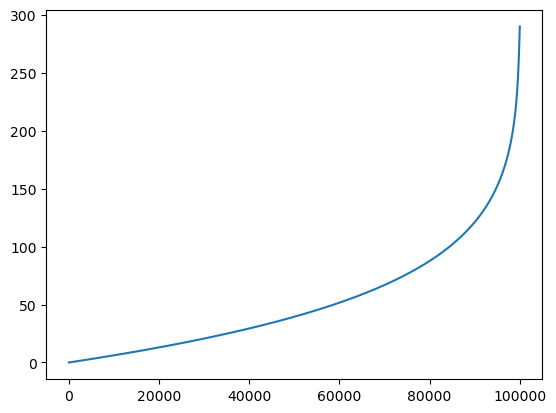

In [10]:
print('Courant', Kf*A[0]**m*dt/dx)

h = np.zeros_like(x)

for step in range(nstep):
    h[1:] = h[1:] + dt*U - dt*Kf*A[:-1]**m*((h[1:] - h[:-1])/dx)**n
plt.plot(x,h);

We see that the steady-state solution is a concave river profile. The predictions of the SPL fit the global observation that rivers have, for the most of concave shape. We can derive an analytical solution for that steady-state solution which we will use to verify the accuracy of our numerical model.

At steady-state, we have that channel incisoin must perfectly balance upllift rate at all points along the river profile:

$$K_f\bigl(k(x_l-x)^p\bigr)^m\Bigl(\frac{\partial h}{\partial x}\Bigr)^n=U$$

By rearranging, we obtain:

$$\frac{\partial h}{\partial x}=\Bigl(\frac{U}{K_fk^m}\Bigr)^{1/n}(x_l-x)^{-mp/n}$$

which we can integrate to obtain:

$$h=C-\Bigl(\frac{U}{K_fk^m}\Bigr)^{1/n}\frac{(x_l-x)^{1-mp/n}}{1-mp/n}$$

where $C$ is an arbitrary constant that can be fixed by considering the boundary condition $h(x=0)=0$:

$$h=\Bigl(\frac{U}{K_fk^m}\Bigr)^{1/n}\Bigl(\frac{x_l^{1-mp/n}}{1-mp/n}-\frac{(x_l-x)^{1-mp/n}}{1-mp/n}\Bigr)$$

and we can finally write:

$$h=\Bigl(\frac{U}{K_fk^m}\Bigr)^{1/n}\frac{x_l^{1-mp/n}}{1-mp/n}\Bigl(1-(1-x')^{1-mp/n}\Bigr)$$

where $x'=x/x_l$.

This results demonstrates that according to the SPL, all steayd-state profiles should have the same shape if scaled by their length, $x_l$, and their height, $h_l$,<br>
where $h_l=\Bigl(\frac{U}{K_fk^m}\Bigr)^{1/n}\frac{x_l^{1-mp/n}}{1-mp/n}$.

Let's check now if our numerical solution is accurate by comparing it to this analytical solution.

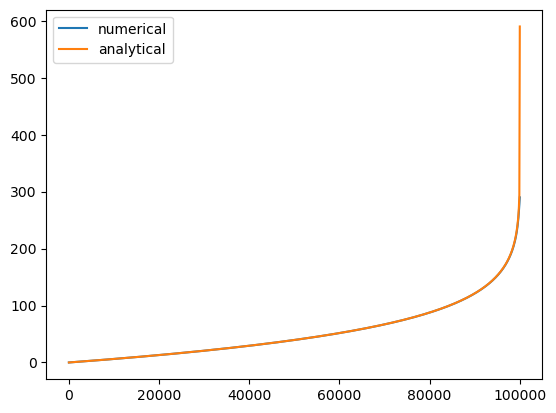

In [14]:
h = np.zeros_like(x)

for step in range(nstep):
    h[1:] = h[1:] + dt*U - dt*Kf*A[:-1]**m*((h[1:] - h[:-1])/dx)**n

ha = (U/Kf/k**m)**(1/n)*xl**(1-m*p/n)/(1-m*p/n)*(1-(1-x/xl)**(1-m*p/n))

plt.plot(x,h, label='numerical')
plt.plot(x,ha, label='analytical')

plt.legend();

We see that the two solution are almost identical except near the top of the profile. This is because the system has not yet reached perfect steady-state.

The analytical expression shows us that the height of the profile or the so-called `basin relief` is proportional to the uplift rate, $U$ and to the precipitation rate to the power $\nu^m$, through $K_f$. We can check that numerically:

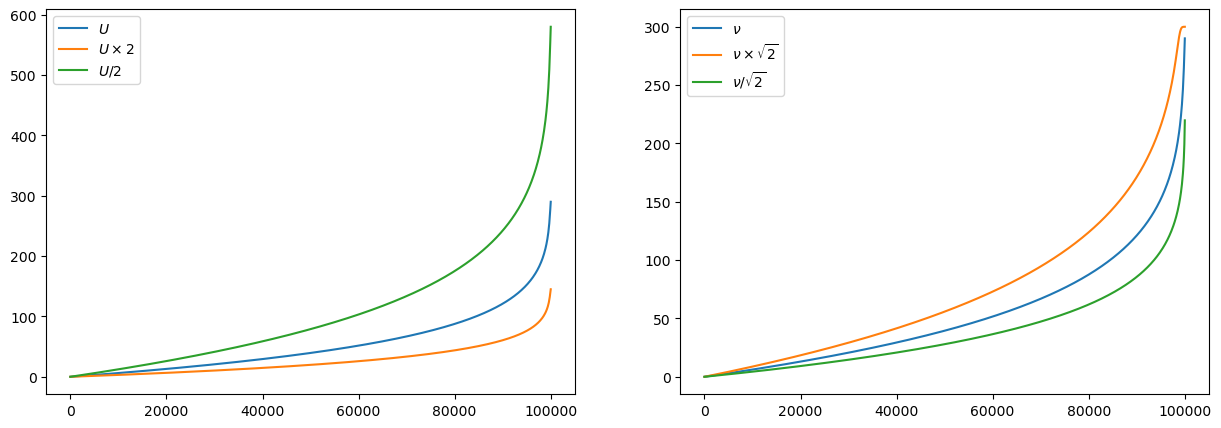

In [26]:
fig, ax = plt.subplots(ncols=2, figsize=(15,5))

h = np.zeros_like(x)
h1 = np.zeros_like(x)
h2 = np.zeros_like(x)
h3 = np.zeros_like(x)
h4 = np.zeros_like(x)

for step in range(nstep):
    h[1:] = h[1:] + dt*U - dt*Kf*A[:-1]**m*((h[1:] - h[:-1])/dx)**n
    h1[1:] = h1[1:] + dt*U/2 - dt*Kf*A[:-1]**m*((h1[1:] - h1[:-1])/dx)**n
    h2[1:] = h2[1:] + dt*U*2 - dt*Kf*A[:-1]**m*((h2[1:] - h2[:-1])/dx)**n
    h3[1:] = h3[1:] + dt*U - dt*Kf/np.sqrt(2)*A[:-1]**m*((h3[1:] - h3[:-1])/dx)**n
    h4[1:] = h4[1:] + dt*U - dt*Kf*np.sqrt(2)*A[:-1]**m*((h4[1:] - h4[:-1])/dx)**n

ax[0].plot(x,h, label=r'$U$')
ax[0].plot(x,h1, label=r'$U\times 2$')
ax[0].plot(x,h2, label=r'$U/2$')
ax[0].legend()

ax[1].plot(x,h, label=r'$\nu$')
ax[1].plot(x,h3, label=r'$\nu\times\sqrt{2}$')
ax[1].plot(x,h4, label=r'$\nu/\sqrt{2}$')
ax[1].legend();


We can further check our solution by showing if our model also predicts the observed loglog Slope-Area relationship observed along many river profiles:

![Hack, 1957](./SlopeArea.jpg)

We see that this relationship seems to be a function of lithology when the uplift rate can be assumed constant.

We can explain it from the SPL at steady-state:

$$U-K_fA^mS^n=0$$

which implies that:

$$\log{S} = \log{\Bigl(\frac{U}{K_f}\Bigr)^{1/n}}-\frac{m}{n}\log{A}$$

The coefficient $\Bigl(\frac{U}{K_f}\Bigr)^{1/n}$ is called the steepness index and $\frac{m}{n}$ the concavity.

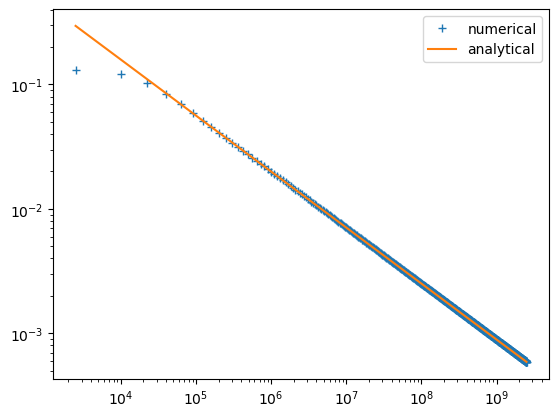

In [19]:
plt.loglog(A[:-1], (h[1:] - h[:-1])/dx,'+', label='numerical')
plt.loglog(A[:-1], (U/Kf)**(1/n)*A[:-1]**(-m/n), label='analytical')

plt.legend();

And we see that the model predictions agree with the analytical solution except at small drainage area, i.e., near the top of the profile, confirming that the system has not yet reached perfect steady-state.

Let's now consider the transient solution.

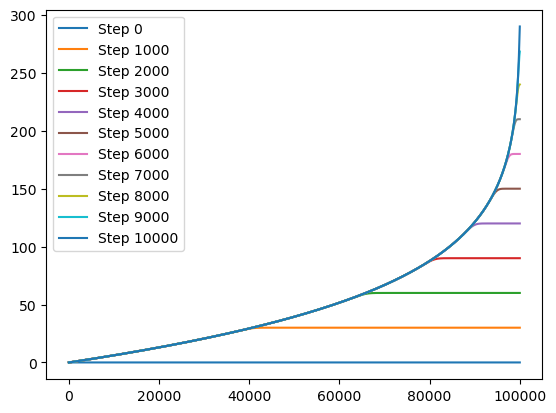

In [27]:
h = np.zeros_like(x)

for step in range(nstep):
    h[1:] = h[1:] + dt*U - dt*Kf*A[:-1]**m*((h[1:] - h[:-1])/dx)**n
    if step%(nstep//10)==0:
        plt.plot(x, h, label=f'Step {step}')
        
plt.legend();

We see that the solution is made of two parts on each side of inflection point in the river profile. To the left of the inflection point, the solution is equal to the steady-state or graded solution; to the right of it the solution is the initial solution transposed vertically. This behaviour of the SPL is very similar to the formation and propagation of knickpoints observed in many river profiles.

![Whittaker et al, 2012](./Whittaker.jpg)

The propagation velocity of a knickpoint is equal to $v_p=K_fA^m$ when $n=1$. The drainage are dependence explains why the knickpoint slows down as it migrates up the profile.

We can finally explore the effect of changing the uplift rate or the precipitation rate on a river profile and the propagation of kinckpoints.

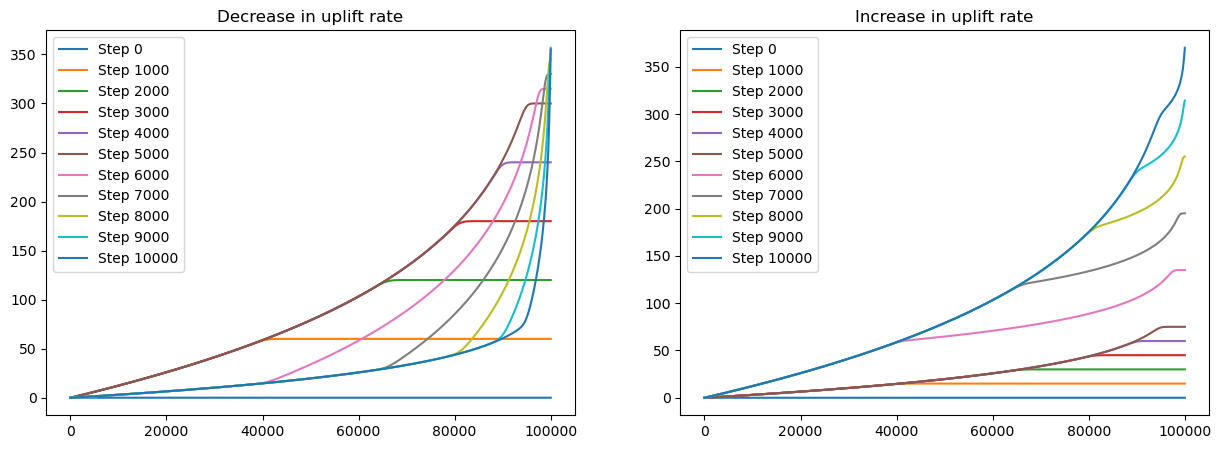

In [32]:
fig,ax = plt.subplots(ncols=2, figsize=(15,5))

hl = np.zeros_like(x)
hr = np.zeros_like(x)

Ul = U*2
Ur = U/2
for step in range(nstep):
    if step>nstep//2:
        Ul = U/2
        Ur = U*2
    hl[1:] = hl[1:] + dt*Ul - dt*Kf*A[:-1]**m*((hl[1:] - hl[:-1])/dx)**n
    hr[1:] = hr[1:] + dt*Ur - dt*Kf*A[:-1]**m*((hr[1:] - hr[:-1])/dx)**n
    if step%(nstep//10)==0:
        ax[0].plot(x, hl, label=f'Step {step}')
        ax[1].plot(x, hr, label=f'Step {step}')

ax[0].legend()
ax[1].legend()

ax[0].set_title('Decrease in uplift rate')
ax[1].set_title('Increase in uplift rate');

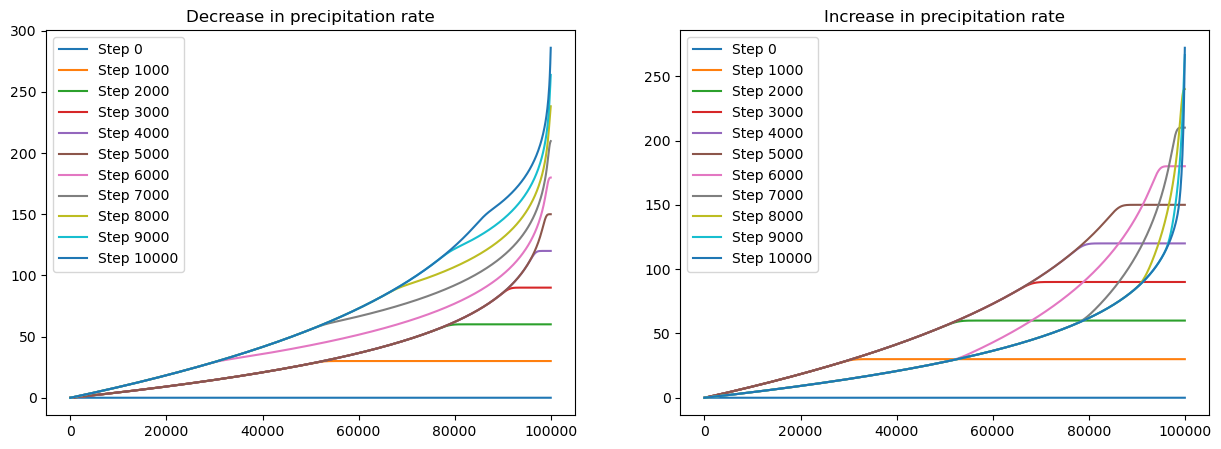

In [33]:
fig,ax = plt.subplots(ncols=2, figsize=(15,5))

hl = np.zeros_like(x)
hr = np.zeros_like(x)

Kfl = Kf*np.sqrt(2)
Kfr = Kf/np.sqrt(2)
for step in range(nstep):
    if step>nstep//2:
        Kfl = Kf/np.sqrt(2)
        Kfr = Kf*np.sqrt(2)
    hl[1:] = hl[1:] + dt*U - dt*Kfl*A[:-1]**m*((hl[1:] - hl[:-1])/dx)**n
    hr[1:] = hr[1:] + dt*U - dt*Kfr*A[:-1]**m*((hr[1:] - hr[:-1])/dx)**n
    if step%(nstep//10)==0:
        ax[0].plot(x, hl, label=f'Step {step}')
        ax[1].plot(x, hr, label=f'Step {step}')

ax[0].legend()
ax[1].legend()

ax[0].set_title('Decrease in precipitation rate')
ax[1].set_title('Increase in precipitation rate');

We see that abrupt variations in either $U$ or $\nu$ create knickpoints that propagates up the profile. Natural river profiles have been used to infer variations in precipitation and (mostly) uplift rate. This has even been done at the continantel level by considering many rivers (for example in Africa) and inverting their profiles (and the position and geometry of knickpoints) to generate 2D maps of uplift rate through geological time and thus passed topography maps. This, however, relies on the knowledge of $K_f$ which is hiughly problematic. To circumvene the large uncertainty this leads to, one usually considers independent observations zt a few key locations.

![Rudge et al, 2015](./Rudge1.jpg)

![Rudge et al, 2015](./Rudge2.jpg)